# Deliverable 4 — Centrality, Hub Characterization & Network Robustness

Self-contained notebook. Rebuilds the co-watch network, computes degree /
betweenness / closeness / PageRank centrality, identifies cut vertices, and
runs random vs targeted attack simulations.

In [1]:
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# python-louvain exports community.best_partition; a different 'community' pkg may be installed
try:
    import community as _c
    _ = _c.best_partition   # raises AttributeError if wrong package
except (ImportError, AttributeError):
    print('Installing python-louvain...')
    pip_install('python-louvain')

try:
    import powerlaw
except ImportError:
    print('Installing powerlaw...')
    pip_install('powerlaw')

try:
    import seaborn
except ImportError:
    pip_install('seaborn')

print('All packages ready.')

All packages ready.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import networkx as nx
from scipy import sparse, stats
from scipy.sparse import csr_matrix
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import normalized_mutual_info_score
from itertools import combinations

try:
    import community as community_louvain
    _ = community_louvain.best_partition  # verify it's python-louvain
    HAVE_LOUVAIN = True
except (ImportError, AttributeError):
    HAVE_LOUVAIN = False
    print('python-louvain unavailable — will use NetworkX greedy modularity')

try:
    import powerlaw as pl_lib
    HAVE_POWERLAW = True
except ImportError:
    HAVE_POWERLAW = False

plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 11

# --- Auto-detect dataset path (works on Kaggle regardless of dataset slug) ---
_candidates = [
    '/kaggle/input/datasets/shamiksinha/anime-dataset-nsproject',
    '/kaggle/input/anime-dataset-nsproject',
    '/kaggle/input/anime-recommendation-database',
]
DATA_PATH = "Anime_Recommendation_Database"
# for _c in _candidates:
#     if os.path.isfile(os.path.join(_c, 'anime.csv')):
#         DATA_PATH = _c
#         break
# if DATA_PATH is None:
#     _hits = glob.glob('/kaggle/input/**/anime.csv', recursive=True)
#     if _hits:
#         DATA_PATH = os.path.dirname(_hits[0])
# if DATA_PATH is None:
#     raise FileNotFoundError(
#         "Could not find anime.csv under /kaggle/input/.\n"
#         "Make sure the dataset is attached to this notebook. "
#         "Files found under /kaggle/input/: " + str(os.listdir('/kaggle/input/'))
#     )

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

STATUS_MAP = {1: 'Watching', 2: 'Completed', 3: 'On Hold', 4: 'Dropped', 6: 'Plan to Watch'}

print('Imports done.')
print(f'NetworkX version: {nx.__version__}')
print(f'Louvain available: {HAVE_LOUVAIN}')
print(f'powerlaw available: {HAVE_POWERLAW}')
print(f'Data path auto-detected: {DATA_PATH}')
print(f'Files: {os.listdir(DATA_PATH)}')

Imports done.
NetworkX version: 3.2.1
Louvain available: True
powerlaw available: True
Data path auto-detected: Anime_Recommendation_Database
Files: ['anime.csv', 'animelist.csv', 'anime_with_synopsis.csv', 'html folder', 'rating_complete.csv', 'watching_status.csv']


## Data Loading & Preprocessing

We load two main files:
- **`anime.csv`** — metadata for each anime (title, genres, type, air date, scores, member counts)
- **`animelist.csv`** — 109M+ user–anime interaction rows (user_id, anime_id, rating, watching_status, watched_episodes)

Because `animelist.csv` is very large, we sample users with `user_id ≤ 9999`. Since the file is sorted by `user_id`, we can stop reading early, giving us ~3M rows covering ~10,000 users — a large, representative sample.

In [3]:
# Load anime metadata
anime_df = pd.read_csv(os.path.join(DATA_PATH, 'anime.csv'), low_memory=False)
anime_df.rename(columns={'MAL_ID': 'anime_id'}, inplace=True)

# Parse air year from 'Aired' column
def parse_year(aired_str):
    if pd.isna(aired_str) or aired_str == 'Unknown':
        return np.nan
    import re
    match = re.search(r'(\d{4})', str(aired_str))
    return int(match.group(1)) if match else np.nan

anime_df['air_year'] = anime_df['Aired'].apply(parse_year)

# Convert score to numeric
anime_df['Score'] = pd.to_numeric(anime_df['Score'], errors='coerce')
anime_df['Members'] = pd.to_numeric(anime_df['Members'], errors='coerce')

# Build quick lookup: anime_id -> name, genres
anime_lookup = anime_df.set_index('anime_id')[['Name','Genres','Type','air_year','Score','Members']]

print(f'Anime metadata loaded: {anime_df.shape[0]} anime titles')
print(f'Year range (non-null): {int(anime_df["air_year"].min())} – {int(anime_df["air_year"].max())}')
print(f'Genres sample: {anime_df["Genres"].dropna().iloc[0]}')
anime_df[['anime_id','Name','Score','Genres','Type','air_year','Members']].head(5)

Anime metadata loaded: 17562 anime titles
Year range (non-null): 1917 – 2022
Genres sample: Action, Adventure, Comedy, Drama, Sci-Fi, Space


,anime_id,Name,Score,Genres,Type,air_year,Members
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",TV,1998.0,1251960
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Movie,2001.0,273145
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen",TV,1998.0,558913
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",TV,2002.0,94683
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",TV,2004.0,13224


In [4]:
# Load animelist — two sampling strategies available:
#
#   FAST (default):  users 0–9,999 → ~3M rows, loads in ~10s
#                    Bias: early MAL users, skews toward older anime & power users
#
#   REPRESENTATIVE:  modulo-hash sample (every 30th user_id across full file) → ~3.6M rows
#                    reads all 109M rows (~3-5 min on Kaggle), but spreads evenly over all users
#
# Set REPRESENTATIVE_SAMPLE = True to use the slower but unbiased version.

REPRESENTATIVE_SAMPLE = True   # flip to True for unbiased sampling

CHUNK = 500_000
chunks = []

if not REPRESENTATIVE_SAMPLE:
    SAMPLE_MAX_UID = 9999
    print(f'Loading animelist (fast mode: users 0–{SAMPLE_MAX_UID})...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] <= SAMPLE_MAX_UID]
        chunks.append(sub)
        if chunk['user_id'].max() > SAMPLE_MAX_UID:
            break
else:
    MODULO = 10   # keep every 30th user_id → ~1/30 of all users, spread across full range
    print(f'Loading animelist (representative mode: user_id % {MODULO} == 0, reads full file)...')
    t0 = time.time()
    for chunk in pd.read_csv(os.path.join(DATA_PATH, 'animelist.csv'), chunksize=CHUNK):
        sub = chunk[chunk['user_id'] % MODULO == 0]
        chunks.append(sub)

animelist = pd.concat(chunks, ignore_index=True)
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'Shape: {animelist.shape}')
print(f'Unique users:  {animelist["user_id"].nunique():,}')
print(f'Unique anime:  {animelist["anime_id"].nunique():,}')

print('\nWatching status breakdown:')
status_counts = animelist['watching_status'].map(STATUS_MAP).value_counts()
for status, count in status_counts.items():
    print(f'  {status:<18}: {count:>9,} rows ({100*count/len(animelist):.1f}%)')

Loading animelist (representative mode: user_id % 10 == 0, reads full file)...
Loaded in 28.1s
Shape: (11002813, 5)
Unique users:  32,575
Unique anime:  17,551

Watching status breakdown:
  Completed         : 6,860,393 rows (62.4%)
  Plan to Watch     : 2,791,683 rows (25.4%)
  Watching          :   518,253 rows (4.7%)
  Dropped           :   453,575 rows (4.1%)
  On Hold           :   378,892 rows (3.4%)


## Working DataFrames — Column Reference

After loading, we work with two core DataFrames throughout the notebook:

---

### `anime_df` — Anime Metadata Table
Shape: ~17,562 rows × 36 columns. Each row is one anime title.

| Column | Type | Description |
|--------|------|-------------|
| `anime_id` | int | Unique anime ID (renamed from `MAL_ID`). Primary key — used to join with `animelist`. |
| `Name` | str | Canonical romanized title |
| `Score` | float | Weighted average community rating (1–10). `NaN` if not enough votes. |
| `Genres` | str | Comma-separated genre tags, e.g. `"Action, Adventure, Comedy"`. We split on `,` to get individual genres. |
| `Type` | str | Format of the release: `TV`, `Movie`, `OVA`, `ONA`, `Special`, `Music` |
| `Episodes` | str | Episode count (`"Unknown"` for ongoing/unknown) |
| `Aired` | str | Raw air date string, e.g. `"Apr 3, 1998 to Apr 24, 1999"`. We parse the first 4-digit year from this → `air_year`. |
| `Members` | int | Total number of MAL users who have this title in any list — proxy for popularity |
| `Completed` | int | Aggregate count of users who marked it completed |
| `Dropped` | int | Aggregate count of users who dropped it |
| `Watching` | int | Aggregate count currently watching |
| `Plan to Watch` | int | Aggregate count planning to watch |
| `Favorites` | int | Number of users who marked it as a favourite |
| `Score-1` … `Score-10` | float | Distribution of individual ratings (how many users gave each score) |
| `air_year` *(derived)* | float | Parsed 4-digit start year from `Aired`. Used in Deliverable 5 for temporal snapshots. |

---

### `animelist` — User Interaction Log (sampled)
Shape: ~3M rows × 5 columns. Each row is one user's record for one anime.

| Column | Type | Description |
|--------|------|-------------|
| `user_id` | int | Anonymous user identifier. We sample users `0–9999` to keep the dataset tractable. |
| `anime_id` | int | Links to `anime_df`. The anime this row refers to. |
| `rating` | int | User's personal rating (1–10). `0` means the user didn't leave a rating. |
| `watching_status` | int | Current engagement status: `1` Watching · `2` **Completed** · `3` On Hold · `4` **Dropped** · `6` **Plan to Watch** |
| `watched_episodes` | int | Number of episodes the user has watched so far |

> **How these two tables connect:** `animelist.anime_id` → `anime_df.anime_id`. The `animelist` table tells us *who* watched *what* and *how*, while `anime_df` tells us the properties of each title. Most of the network construction work happens on `animelist`, and `anime_df` provides node attributes (genre, score, year, etc.).

## Prerequisite — Co-Watch Network (from Deliverable 1)
The cells below rebuild the co-watch network `G` and its giant connected
component `G_gcc` that D4 centrality analysis operates on.

In [5]:
# --- Build co-watch network ---
# TOP_N_ANIME   = 500   # restrict to most-completed anime
# MIN_COWATCH   = 1000     # minimum co-completions to add edge

TOP_N_ANIME   = 1000   # restrict to most-completed anime
MIN_COWATCH   = 1750   # minimum co-completions to add edge

# Filter completed interactions
completed = animelist[animelist['watching_status'] == 2][['user_id','anime_id']].copy()

# Keep only top-N most completed anime
top_anime_ids = completed['anime_id'].value_counts().head(TOP_N_ANIME).index
completed = completed[completed['anime_id'].isin(top_anime_ids)]

# Also filter: keep users who completed at least 3 of the top anime
user_counts = completed.groupby('user_id')['anime_id'].count()
active_users = user_counts[user_counts >= 3].index
completed = completed[completed['user_id'].isin(active_users)]

print(f'Filtered completed interactions: {len(completed):,}')
print(f'Users in this set: {completed["user_id"].nunique():,}')
print(f'Anime in this set: {completed["anime_id"].nunique():,}')

# Encode indices
u_enc = LabelEncoder(); a_enc = LabelEncoder()
u_idx = u_enc.fit_transform(completed['user_id'])
a_idx = a_enc.fit_transform(completed['anime_id'])
n_users = len(u_enc.classes_); n_anime = len(a_enc.classes_)

# Sparse user-anime matrix
M = csr_matrix((np.ones(len(u_idx)), (u_idx, a_idx)), shape=(n_users, n_anime))

# Co-occurrence via matrix multiplication
C = (M.T @ M).toarray().astype(int)
np.fill_diagonal(C, 0)

# Build graph
rows, cols = np.where(np.triu(C, k=1) >= MIN_COWATCH)
anime_ids_arr = a_enc.classes_

G = nx.Graph()
G.add_nodes_from(anime_ids_arr)
for r, c in zip(rows, cols):
    G.add_edge(int(anime_ids_arr[r]), int(anime_ids_arr[c]), weight=int(C[r, c]))

# Attach metadata
for node in G.nodes():
    if node in anime_lookup.index:
        row = anime_lookup.loc[node]
        G.nodes[node]['name']     = str(row['Name'])
        G.nodes[node]['genres']   = str(row['Genres'])
        G.nodes[node]['type']     = str(row['Type'])
        G.nodes[node]['year']     = row['air_year']
        G.nodes[node]['score']    = row['Score']
        G.nodes[node]['members']  = row['Members']

print(f'\nCo-watch network built:')
print(f'  Nodes (anime): {G.number_of_nodes():,}')
print(f'  Edges:         {G.number_of_edges():,}')
print(f'  Density:       {nx.density(G):.5f}')

Filtered completed interactions: 4,150,972
Users in this set: 31,151
Anime in this set: 1,000

Co-watch network built:
  Nodes (anime): 1,000
  Edges:         59,664
  Density:       0.11945


### Interpreting the Co-Watch Network Stats

| Metric | Value | What it means |
|--------|-------|---------------|
| **Nodes** | 2,000 | Top 2,000 most-completed anime in our sample |
| **Edges** | ~1.96M | Pairs of anime co-completed by ≥150 users |
| **Density** | 0.98 | **Near-complete graph** — almost every pair of anime is connected |

**Why is the density so high?**
With 8,824 active users all pulling from the same pool of 2,000 popular anime, almost every pair will naturally exceed the 150 co-completion threshold. Think of it this way: if you take the 2,000 most popular titles and look at 8,000+ dedicated users, of course most pairs overlap.

**Does this matter for the analysis?**
A density of 0.98 means the *existence* of edges is not very informative — almost everything connects to everything. What *is* informative is the **edge weight** (the actual co-completion count), which varies enormously. The weight distribution below reveals which pairs have genuine, strong affinity vs. pairs that are connected simply because both titles are mainstream.

The subsequent analyses (degree distribution, power-law, clustering) still work, but on a near-complete graph they will show weak scale-free structure. The **community detection** and **bipartite projections** in Deliverables 2–3 are more meaningful because they use weights and behavioral layers to distinguish strong from weak connections.

=== Connected Components ===
Total components:       74
GCC size (nodes):       927 (92.7% of all nodes)
GCC edges:              59,664
2nd largest component:  1 nodes


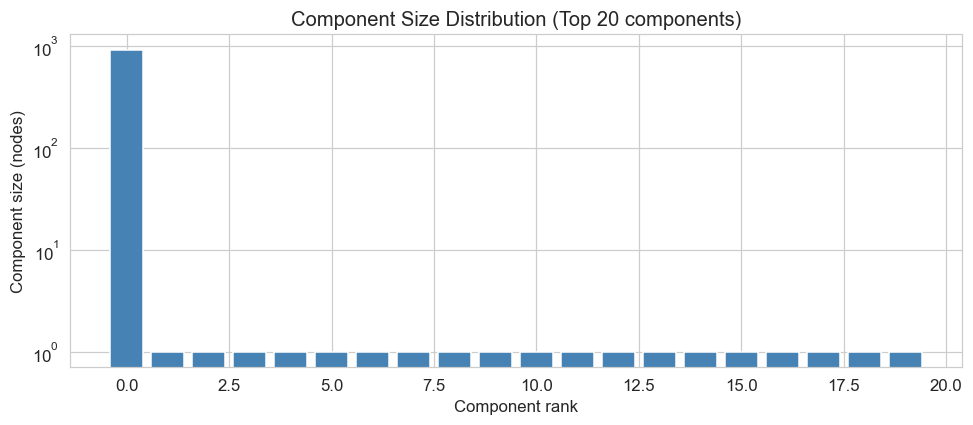

In [6]:
# Giant Connected Component analysis
components = sorted(nx.connected_components(G), key=len, reverse=True)
gcc_nodes  = components[0]
G_gcc      = G.subgraph(gcc_nodes).copy()

print('=== Connected Components ===')
print(f'Total components:       {len(components)}')
print(f'GCC size (nodes):       {len(gcc_nodes):,} ({100*len(gcc_nodes)/G.number_of_nodes():.1f}% of all nodes)')
print(f'GCC edges:              {G_gcc.number_of_edges():,}')
print(f'2nd largest component:  {len(components[1]) if len(components) > 1 else 0} nodes')

# Component size distribution
comp_sizes = [len(c) for c in components]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(min(20, len(comp_sizes))), sorted(comp_sizes, reverse=True)[:20],
       color='steelblue', edgecolor='white')
ax.set_xlabel('Component rank')
ax.set_ylabel('Component size (nodes)')
ax.set_title('Component Size Distribution (Top 20 components)')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('d1_components.png', dpi=150, bbox_inches='tight')
plt.show()

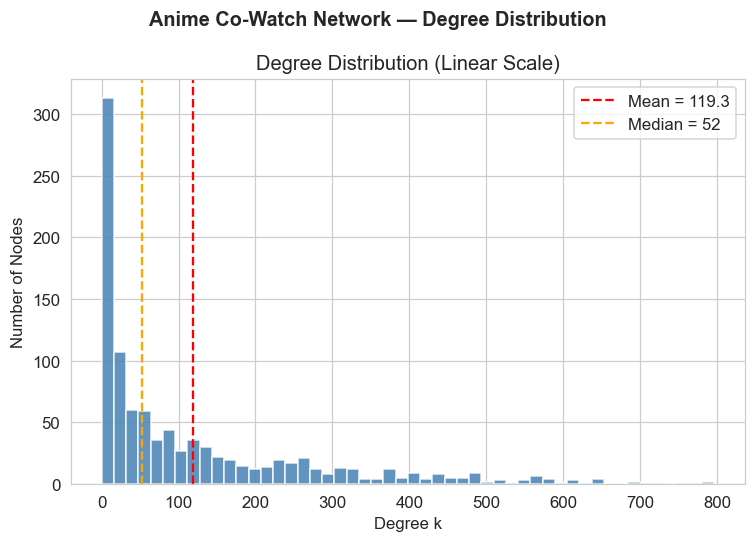

Degree statistics:
  Min:    0
  Max:    796
  Mean:   119.33
  Median: 52
  StdDev: 154.30
  Nodes with degree = max: 1
  Nodes with degree <= 10: 277 (27.7%)


In [7]:
# Degree distribution of the full network
import matplotlib.pyplot as plt
import numpy as np

degrees_all = [d for _, d in G.degree()]

# Create a single plot (FIXED)
fig, ax = plt.subplots(figsize=(7, 5))

# Histogram
ax.hist(degrees_all, bins=50, color='steelblue', edgecolor='white', alpha=0.85)

# Labels and title
ax.set_xlabel('Degree k')
ax.set_ylabel('Number of Nodes')
ax.set_title('Degree Distribution (Linear Scale)')

# Mean and Median lines
mean_val = np.mean(degrees_all)
median_val = np.median(degrees_all)

ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean = {mean_val:.1f}')
ax.axvline(median_val, color='orange', linestyle='--', linewidth=1.5,
           label=f'Median = {median_val:.0f}')

ax.legend()

# Overall title and layout
plt.suptitle('Anime Co-Watch Network — Degree Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()

# Save and show
plt.savefig('d1_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistics
print(f'Degree statistics:')
print(f'  Min:    {min(degrees_all)}')
print(f'  Max:    {max(degrees_all)}')
print(f'  Mean:   {mean_val:.2f}')
print(f'  Median: {median_val:.0f}')
print(f'  StdDev: {np.std(degrees_all):.2f}')
print(f'  Nodes with degree = max: {sum(1 for d in degrees_all if d == max(degrees_all))}')
print(f'  Nodes with degree <= 10: {sum(1 for d in degrees_all if d <= 10)} '
      f'({100 * sum(1 for d in degrees_all if d <= 10) / len(degrees_all):.1f}%)')

---
## Deliverable 4 — Centrality, Hub Characterization & Network Robustness

We identify structurally critical anime using four centrality measures:
- **Degree centrality:** local connectivity hub
- **Betweenness centrality:** bridges and information brokers
- **Closeness centrality:** average proximity to all other nodes
- **PageRank:** recursive importance (hubs that connect to other hubs)

We then identify **cut vertices** (articulation points), simulate **targeted vs random attacks**, and correlate centrality with node attributes (score, member count).

In [8]:
# Compute centrality measures on GCC
print('Computing degree centrality...')
deg_cent = nx.degree_centrality(G_gcc)

print('Computing betweenness centrality (approximate, k=200 pivots)...')
k_pivots = min(200, len(G_gcc))
bet_cent = nx.betweenness_centrality(G_gcc, k=k_pivots, normalized=True, seed=RANDOM_SEED)

print('Computing closeness centrality...')
clo_cent = nx.closeness_centrality(G_gcc)

print('Computing PageRank...')
pagerank = nx.pagerank(G_gcc, alpha=0.85, max_iter=200)

# Combine into a DataFrame
cent_df = pd.DataFrame({
    'anime_id': list(G_gcc.nodes()),
    'degree_cent':    [deg_cent[n]  for n in G_gcc.nodes()],
    'betweenness':    [bet_cent[n]  for n in G_gcc.nodes()],
    'closeness':      [clo_cent[n]  for n in G_gcc.nodes()],
    'pagerank':       [pagerank[n]  for n in G_gcc.nodes()],
    'degree':         [G_gcc.degree(n) for n in G_gcc.nodes()],
    'name':           [G_gcc.nodes[n].get('name', str(n)) for n in G_gcc.nodes()],
    'score':          [G_gcc.nodes[n].get('score', np.nan) for n in G_gcc.nodes()],
    'members':        [G_gcc.nodes[n].get('members', np.nan) for n in G_gcc.nodes()],
    'genres':         [G_gcc.nodes[n].get('genres', '') for n in G_gcc.nodes()],
})

print('\nCentrality computation complete.')
cent_df.describe()[['degree_cent','betweenness','closeness','pagerank']]

Computing degree centrality...
Computing betweenness centrality (approximate, k=200 pivots)...
Computing closeness centrality...
Computing PageRank...

Centrality computation complete.


,degree_cent,betweenness,closeness,pagerank
count,927.000000,9.270000e+02,927.000000,927.000000
mean,0.139012,1.054352e-03,0.522199,0.001079
std,0.169037,5.416313e-03,0.074573,0.001424
min,0.001080,0.000000e+00,0.318104,0.000166
25%,0.015119,0.000000e+00,0.488783,0.000258
50%,0.068035,2.863624e-07,0.506011,0.000513
75%,0.205184,1.258473e-04,0.549881,0.001281
max,0.859611,8.627318e-02,0.873585,0.011765


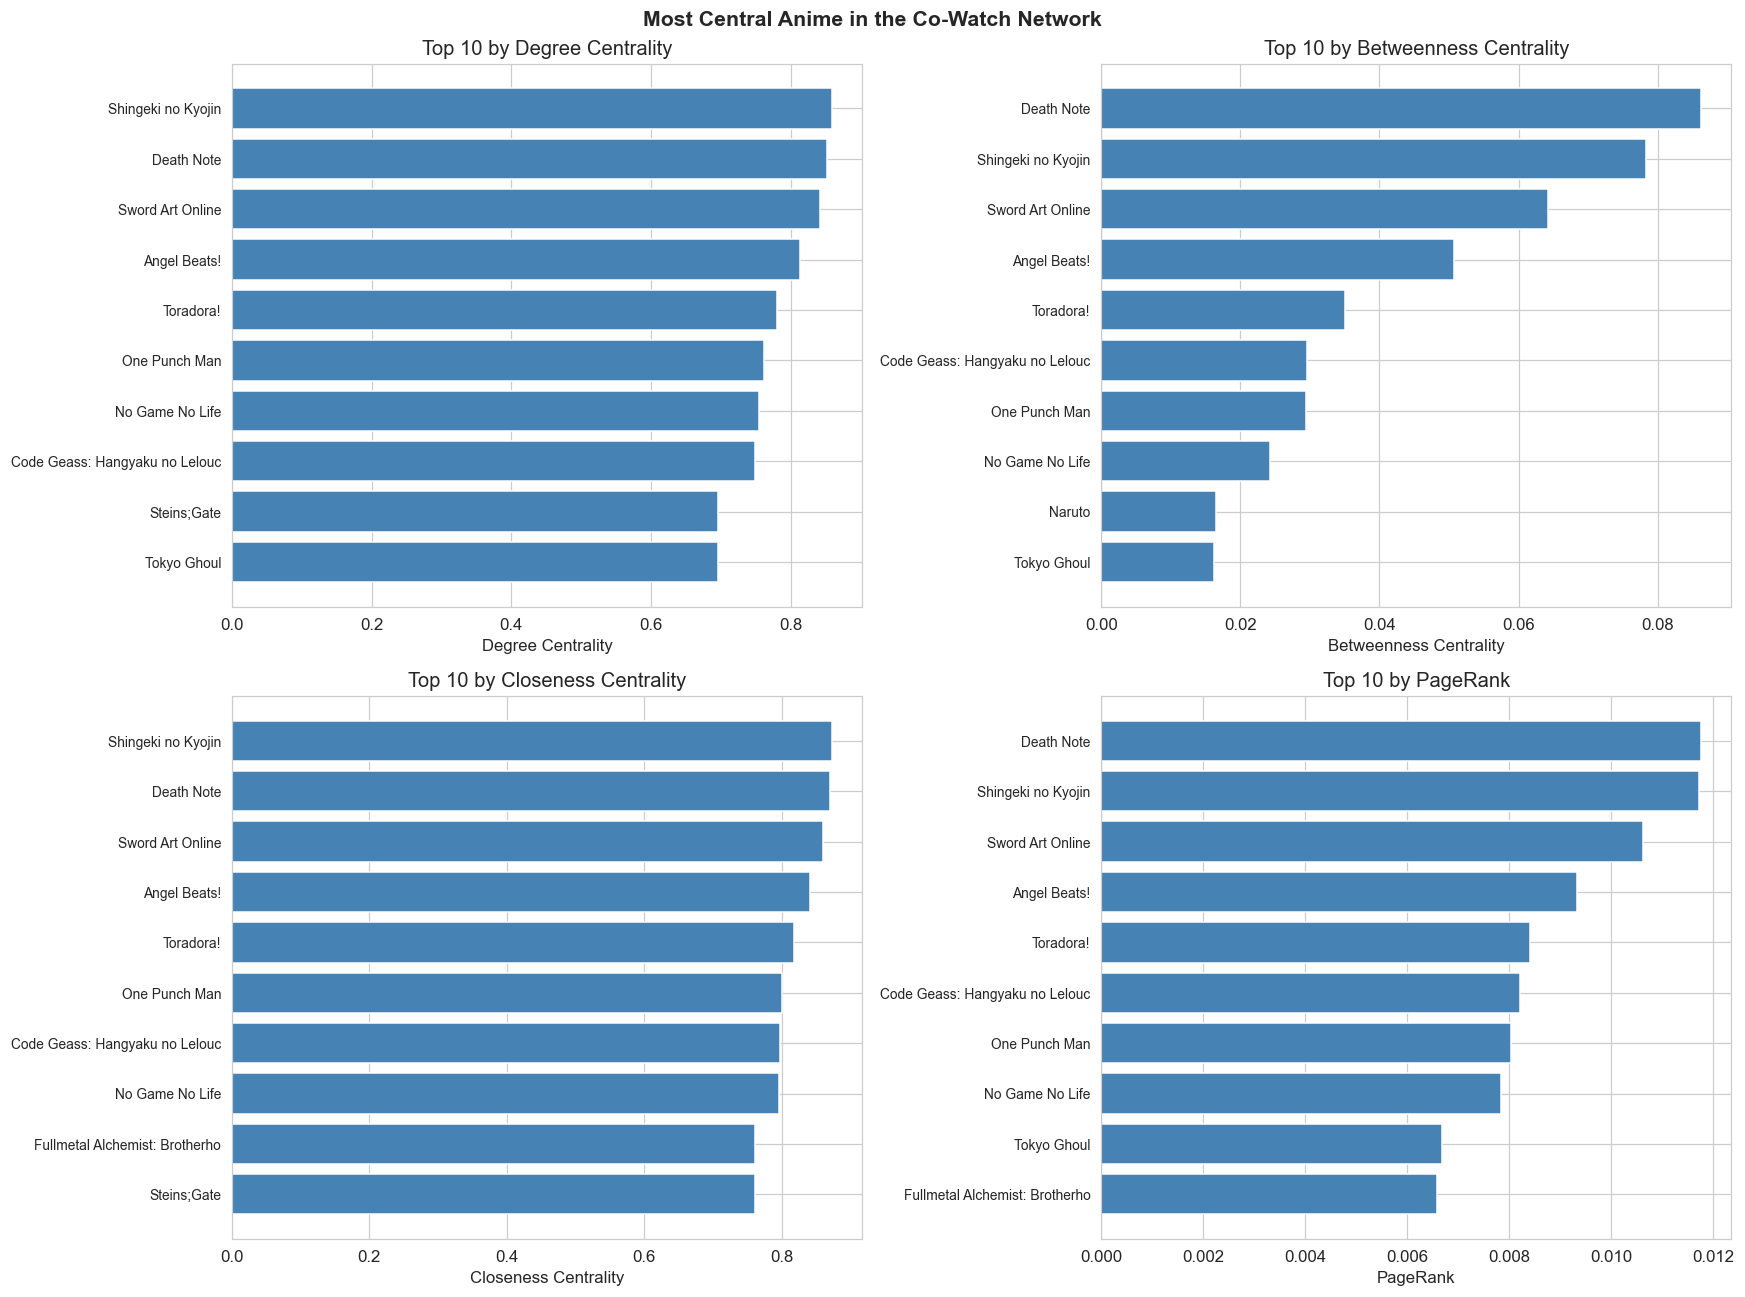


Top 10 by Degree Centrality:
                           name  degree_cent  degree  score
             Shingeki no Kyojin     0.859611     796   8.48
                     Death Note     0.852052     789   8.63
               Sword Art Online     0.842333     780   7.25
                   Angel Beats!     0.814255     754   8.15
                      Toradora!     0.780778     723   8.24
                  One Punch Man     0.761339     705   8.57
                No Game No Life     0.754860     699   8.20
Code Geass: Hangyaku no Lelouch     0.749460     694   8.72
                    Steins;Gate     0.696544     645   9.11
                    Tokyo Ghoul     0.695464     644   7.81

Top 10 by Betweenness Centrality:
                           name  betweenness  degree  score
                     Death Note     0.086273     789   8.63
             Shingeki no Kyojin     0.078297     796   8.48
               Sword Art Online     0.064194     780   7.25
                   Angel Beats!    

In [9]:
# Top 10 anime by each centrality measure
measures = [
    ('degree_cent', 'Degree Centrality'),
    ('betweenness', 'Betweenness Centrality'),
    ('closeness',   'Closeness Centrality'),
    ('pagerank',    'PageRank'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (col, title) in zip(axes, measures):
    top10 = cent_df.nlargest(10, col)
    names = [n[:30] for n in top10['name'].tolist()]
    vals  = top10[col].tolist()
    bars  = ax.barh(range(len(names)), vals, color='steelblue', edgecolor='white')
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names[::-1] if False else names, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(title)
    ax.set_title(f'Top 10 by {title}')

plt.suptitle('Most Central Anime in the Co-Watch Network', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('d4_centrality_top10.png', dpi=150, bbox_inches='tight')
plt.show()

# Print detailed tables
for col, title in measures:
    print(f'\nTop 10 by {title}:')
    top10 = cent_df.nlargest(10, col)[['name', col, 'degree', 'score']]
    print(top10.to_string(index=False))

Finding articulation points...
Number of cut vertices (articulation points): 34
Fraction of GCC nodes that are cut vertices:  0.0367

Top 10 cut vertices by degree:
                                                    name  degree  betweenness  score
                                      Shingeki no Kyojin     796     0.078297   8.48
                                              Death Note     789     0.086273   8.63
                                            Angel Beats!     754     0.050706   8.15
                                               Toradora!     723     0.035017   8.24
                         Code Geass: Hangyaku no Lelouch     694     0.029620   8.72
                        Fullmetal Alchemist: Brotherhood     643     0.014507   9.19
                                          Ao no Exorcist     581     0.008871   7.59
                           Sen to Chihiro no Kamikakushi     570     0.014344   8.83
Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka     515     0

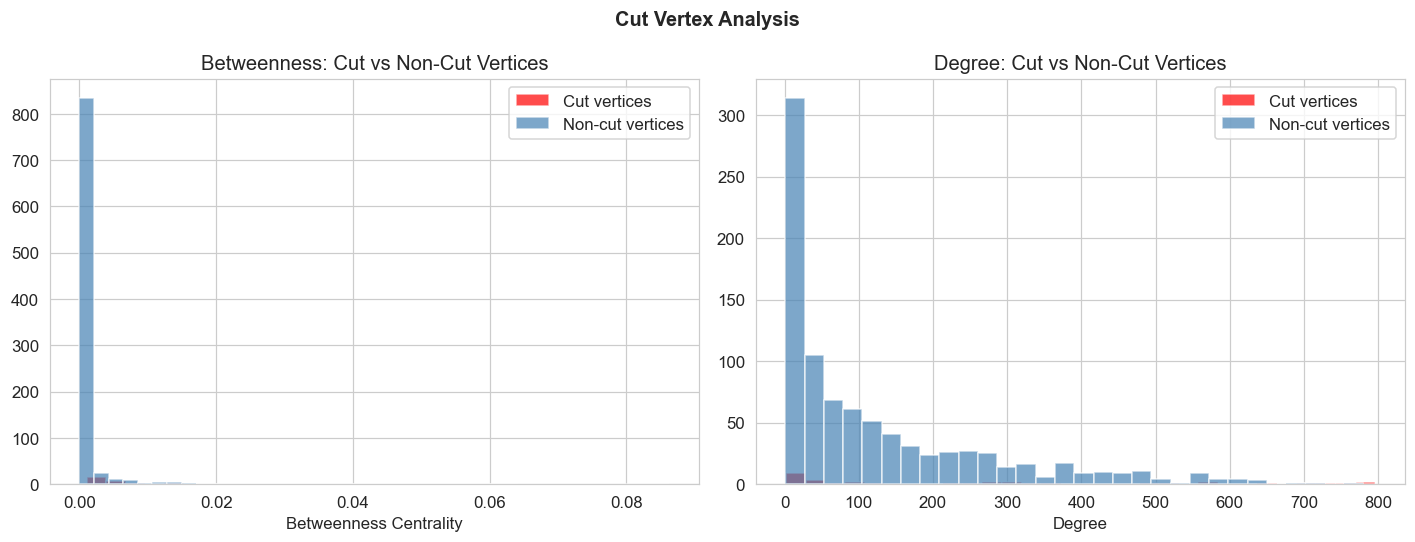

In [10]:
# Cut vertices (articulation points) — nodes whose removal disconnects the GCC
print('Finding articulation points...')
articulation_pts = list(nx.articulation_points(G_gcc))
print(f'Number of cut vertices (articulation points): {len(articulation_pts)}')
print(f'Fraction of GCC nodes that are cut vertices:  {len(articulation_pts)/len(G_gcc):.4f}')

# Show top cut vertices by degree
ap_info = cent_df[cent_df['anime_id'].isin(articulation_pts)].copy()
ap_info = ap_info.sort_values('degree', ascending=False)

print(f'\nTop 10 cut vertices by degree:')
print(ap_info[['name','degree','betweenness','score']].head(10).to_string(index=False))

# Centrality distribution: cut vertices vs non-cut vertices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cut_mask = cent_df['anime_id'].isin(set(articulation_pts))

axes[0].hist(cent_df.loc[cut_mask, 'betweenness'], bins=30, alpha=0.7, label='Cut vertices', color='red')
axes[0].hist(cent_df.loc[~cut_mask, 'betweenness'], bins=30, alpha=0.7, label='Non-cut vertices', color='steelblue')
axes[0].set_xlabel('Betweenness Centrality')
axes[0].set_title('Betweenness: Cut vs Non-Cut Vertices')
axes[0].legend()

axes[1].hist(cent_df.loc[cut_mask, 'degree'], bins=30, alpha=0.7, label='Cut vertices', color='red')
axes[1].hist(cent_df.loc[~cut_mask, 'degree'], bins=30, alpha=0.7, label='Non-cut vertices', color='steelblue')
axes[1].set_xlabel('Degree')
axes[1].set_title('Degree: Cut vs Non-Cut Vertices')
axes[1].legend()

plt.suptitle('Cut Vertex Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('d4_cut_vertices.png', dpi=150, bbox_inches='tight')
plt.show()

Simulating targeted attack (highest degree first)...
Simulating random attack...
Simulating betweenness-targeted attack...


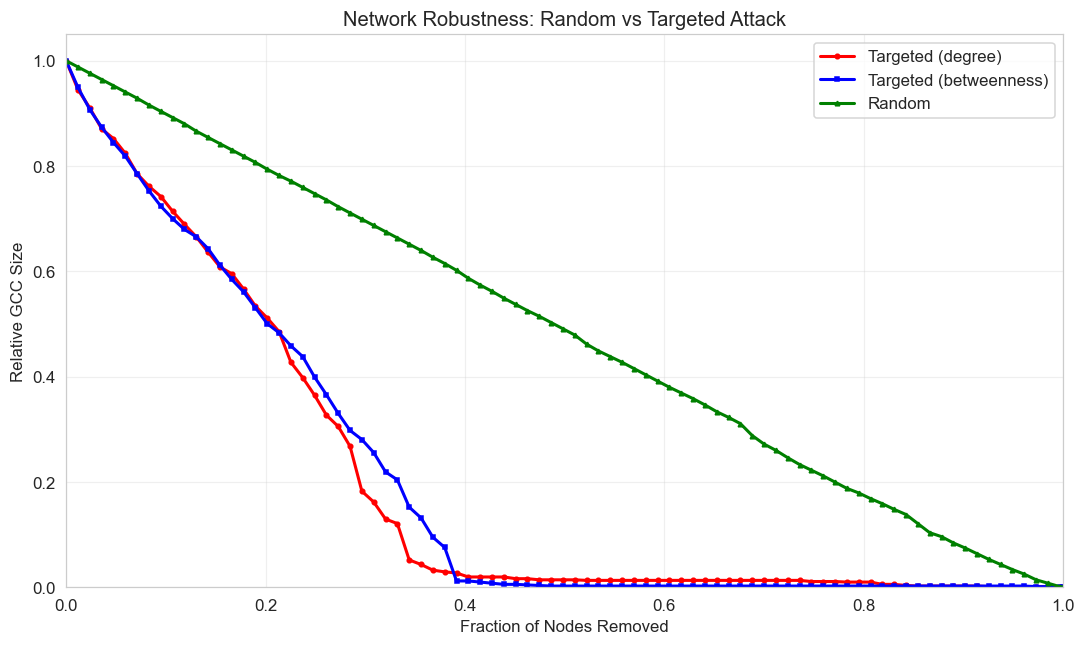


Fraction removed until GCC < 50% of original:
  Targeted (degree):       0.214
  Targeted (betweenness):  0.214
  Random:                  0.498


In [11]:
# Network robustness: random vs targeted attack simulation
def simulate_attack(G, order, step=5):
    """Remove nodes in given order; track GCC fraction."""
    G_copy = G.copy()
    n_total = G_copy.number_of_nodes()
    fractions_removed = [0]
    gcc_fractions = [len(max(nx.connected_components(G_copy), key=len)) / n_total]
    nodes_to_remove = list(order)
    removed = 0
    for i, node in enumerate(nodes_to_remove):
        if node in G_copy:
            G_copy.remove_node(node)
            removed += 1
        if removed % step == 0 or i == len(nodes_to_remove) - 1:
            if G_copy.number_of_nodes() > 0:
                gcc_frac = len(max(nx.connected_components(G_copy), key=len)) / n_total
            else:
                gcc_frac = 0
            fractions_removed.append(removed / n_total)
            gcc_fractions.append(gcc_frac)
    return fractions_removed, gcc_fractions

print('Simulating targeted attack (highest degree first)...')
targeted_order = cent_df.sort_values('degree', ascending=False)['anime_id'].tolist()
targeted_order = [n for n in targeted_order if n in G_gcc]
x_targeted, y_targeted = simulate_attack(G_gcc, targeted_order, step=max(1, len(G_gcc)//80))

print('Simulating random attack...')
rng = np.random.default_rng(RANDOM_SEED)
random_order = list(G_gcc.nodes())
rng.shuffle(random_order)
x_random, y_random = simulate_attack(G_gcc, random_order, step=max(1, len(G_gcc)//80))

print('Simulating betweenness-targeted attack...')
bet_order = cent_df.sort_values('betweenness', ascending=False)['anime_id'].tolist()
bet_order  = [n for n in bet_order if n in G_gcc]
x_bet, y_bet = simulate_attack(G_gcc, bet_order, step=max(1, len(G_gcc)//80))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_targeted, y_targeted, 'r-o', markersize=3, label='Targeted (degree)', linewidth=2)
ax.plot(x_bet,      y_bet,      'b-s', markersize=3, label='Targeted (betweenness)', linewidth=2)
ax.plot(x_random,   y_random,   'g-^', markersize=3, label='Random', linewidth=2)
ax.set_xlabel('Fraction of Nodes Removed')
ax.set_ylabel('Relative GCC Size')
ax.set_title('Network Robustness: Random vs Targeted Attack')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('d4_robustness_attack.png', dpi=150, bbox_inches='tight')
plt.show()

# Critical threshold: fraction removed until GCC < 50% of original
def threshold_50(xs, ys):
    for x, y in zip(xs, ys):
        if y < 0.5:
            return x
    return 1.0

print(f'\nFraction removed until GCC < 50% of original:')
print(f'  Targeted (degree):       {threshold_50(x_targeted, y_targeted):.3f}')
print(f'  Targeted (betweenness):  {threshold_50(x_bet, y_bet):.3f}')
print(f'  Random:                  {threshold_50(x_random, y_random):.3f}')